In [1]:
# 1: Install Dependencies and Mount Drive
!pip install transformers datasets pandas scikit-learn

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2: Import everything needed
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# 3: Load Data
conda_train_path = '/content/drive/MyDrive/FYP_Dataset/CONDA_train.csv'
conda_valid_path = '/content/drive/MyDrive/FYP_Dataset/CONDA_valid.csv'
jigsaw_train_path = '/content/drive/MyDrive/FYP_Dataset/train.csv'

conda_train = pd.read_csv(conda_train_path)
conda_valid = pd.read_csv(conda_valid_path)
jigsaw_df = pd.read_csv(jigsaw_train_path)

print("Both datasets loaded!")

Both datasets loaded!


In [4]:
# 4: Prepare the "Hybrid" Dataset

# 1. Clean CONDA (Gaming Data)
def prep_conda(df):
    df = df.dropna(subset=['utterance', 'intentClass']).copy()
    df['text'] = df['utterance'].astype(str)
    # 1 = Toxic ('E' or 'I'), 0 = Non-Toxic ('O')
    df['labels'] = df['intentClass'].apply(lambda x: 1 if x in ['E', 'I'] else 0)
    return df[['text', 'labels']]

clean_conda_train = prep_conda(conda_train)
clean_conda_valid = prep_conda(conda_valid)

# 2. Clean Jigsaw (General Bad Words)
# Combine the 6 jigsaw labels into a single 1 (Toxic) or 0 (Non-Toxic)
jigsaw_df['labels'] = jigsaw_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].max(axis=1)
jigsaw_df = jigsaw_df.rename(columns={'comment_text': 'text'})
clean_jigsaw = jigsaw_df[['text', 'labels']].dropna()

# 3. BALANCE THE DATA: Get exactly 10,000 Toxic and 10,000 Non-Toxic rows from Jigsaw
available_toxic = clean_jigsaw[clean_jigsaw['labels'] == 1]
n_toxic = min(10000, len(available_toxic))
jigsaw_toxic = available_toxic.sample(n=n_toxic, random_state=42, replace=False)
jigsaw_nontoxic = clean_jigsaw[clean_jigsaw['labels'] == 0].sample(n=n_toxic, random_state=42)

print(f"Using {n_toxic} toxic and {n_toxic} non-toxic Jigsaw samples.")
jigsaw_nontoxic = clean_jigsaw[clean_jigsaw['labels'] == 0].sample(n=10000, random_state=42)

# 4. Mix CONDA and Jigsaw together, and shuffle them
combined_train = pd.concat([clean_conda_train, jigsaw_toxic, jigsaw_nontoxic]).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Convert to Hugging Face format
train_dataset = Dataset.from_pandas(combined_train)
valid_dataset = Dataset.from_pandas(clean_conda_valid) # test on gaming data

print(f"Data combined and balanced! Total Training Rows: {len(combined_train)}")
print(combined_train['labels'].value_counts()) # data is balanced

Using 10000 toxic and 10000 non-toxic Jigsaw samples.
Data combined and balanced! Total Training Rows: 46914
labels
0    31694
1    15220
Name: count, dtype: int64


In [5]:
# CELL 5: Tokenize the text
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_valid = valid_dataset.map(tokenize_function, batched=True)

print("Tokenization complete!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/46914 [00:00<?, ? examples/s]

Map:   0%|          | 0/8973 [00:00<?, ? examples/s]

Tokenization complete!


In [6]:
# 6: Train with Evaluation Metrics

# Calculates Accuracy, F1, Precision, and Recall
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    compute_metrics=compute_metrics, # Uses the rubric defined above
)

print("Starting training...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.187737,0.178247,0.946283,0.856033,0.905243,0.811898
2,0.137389,0.193100,0.942160,0.852599,0.854784,0.850425
3,0.093679,0.221540,0.945726,0.859289,0.876769,0.842493


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8799, training_loss=0.14953293135415724, metrics={'train_runtime': 1747.9496, 'train_samples_per_second': 80.518, 'train_steps_per_second': 5.034, 'total_flos': 4660931655410688.0, 'train_loss': 0.14953293135415724, 'epoch': 3.0})

In [7]:
# 7: Save Model
save_directory = "/content/drive/MyDrive/FYP_Dataset/toxic_gaming_model"

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model saved successfully to {save_directory}!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully to /content/drive/MyDrive/FYP_Dataset/toxic_gaming_model!


FINAL MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.97      0.97      7208
       Toxic       0.88      0.84      0.86      1765

    accuracy                           0.95      8973
   macro avg       0.92      0.91      0.91      8973
weighted avg       0.95      0.95      0.95      8973



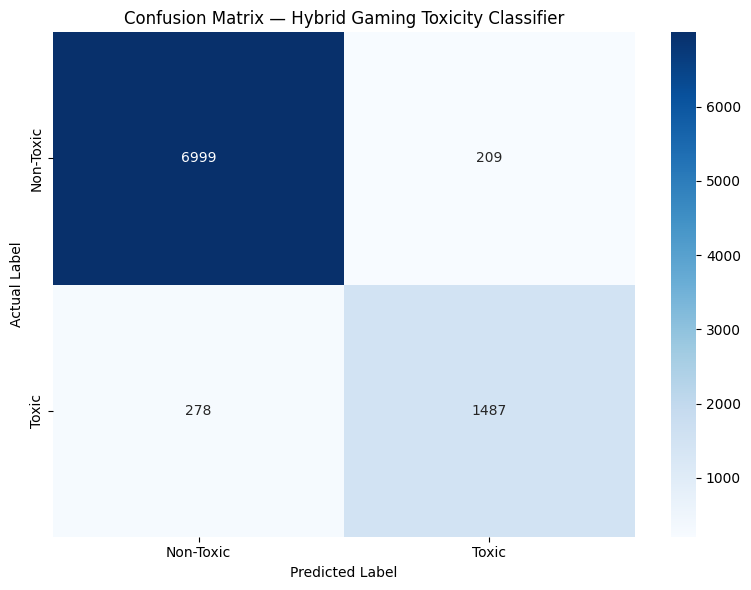

Confusion matrix saved!


In [8]:
# 8: Final Evaluation & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get predictions on validation set
predictions = trainer.predict(tokenized_valid)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Print classification report
print("=" * 50)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * 50)
print(classification_report(labels, preds, target_names=["Non-Toxic", "Toxic"]))

# Plot confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Toxic", "Toxic"],
            yticklabels=["Non-Toxic", "Toxic"])
plt.title('Confusion Matrix — Hybrid Gaming Toxicity Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYP_Dataset/confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved!")